# Funding-aware sign

The plain trend signal takes the sign of the price return over the trailing L weeks. It ignores the funding a hypothetical long would have paid over the same window, which in a hot-funding regime can eat a large fraction of the price move.

This notebook adjusts the trailing return for that funding cost before taking the sign, then checks whether the resulting book earns a higher Sharpe than the plain sign at each L. If funding is high, a barely-positive price return that would have been a loss net of funding should not be a long signal.


## Setup

Load the same weekly close panel, cost table, and funding print series used everywhere else.


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')) if not os.path.exists('loader.py') else '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from loader import (load_daily_panel, weekly_close, cost_round_trip_bps,
                    load_funding_panel, weekly_funding_sum)

daily = load_daily_panel()
weekly = weekly_close(daily)
fwd = weekly.pct_change().shift(-1)
costs = cost_round_trip_bps()

funding = load_funding_panel()
weekly_f = weekly_funding_sum(funding).reindex(weekly.index)
fwd_funding = weekly_f.shift(-1)

print(f'weekly panel {weekly.shape}  weekly funding {weekly_f.shape}')


weekly panel (158, 10)  weekly funding (158, 10)


## Two signals to compare

The plain sign is the sign of the trailing price return over $L$ weeks,

$$s^{\text{plain}}_{i,t} = \text{sign}\!\left(\frac{P_{i,t}}{P_{i,t-L}} - 1\right)$$

The funding-aware sign subtracts the sum of funding prints over the same trailing window,

$$s^{\text{aware}}_{i,t} = \text{sign}\!\left(\frac{P_{i,t}}{P_{i,t-L}} - 1 \;-\; \sum_{k \in [t-L,\ t)} f_{i,k}\right)$$

The subtracted term is what a hypothetical long paid in funding over the window. If price was up by less than that, the net-of-funding trailing return was negative and the funding-aware sign flips short.

The PnL uses the same weekly rebalance, round-trip cost on flips, and realized funding on the held position. We sweep the same five lookbacks and read off the pooled book Sharpe, the delta versus the plain sign, and the fraction of weeks where the two signs disagree.


In [2]:
def signals(L):
    trailing_ret = weekly / weekly.shift(L) - 1.0
    trailing_fund = weekly_f.rolling(L).sum()
    plain = np.sign(trailing_ret)
    aware = np.sign(trailing_ret - trailing_fund)
    return plain, aware

def trend_pnl(sig_df, cost_mult=1.0, include_funding=True):
    parts = []
    for sym in weekly.columns:
        sig = sig_df[sym]
        r = fwd[sym]
        idx = sig.dropna().index.intersection(r.dropna().index)
        sig, r = sig.loc[idx], r.loc[idx]
        f = fwd_funding[sym].reindex(idx).fillna(0.0)
        flips = (sig != sig.shift(1)).astype(float)
        gross = sig * r
        fund_pnl = -sig * f if include_funding else 0.0
        net = gross + fund_pnl - flips * costs[sym] * cost_mult / 1e4
        parts.append(net.rename(sym))
    return pd.concat(parts, axis=1)

def book_sharpe(book):
    return book.mean()/book.std()*np.sqrt(52) if book.std()>0 else np.nan

LOOKBACKS = [1, 2, 4, 8, 12]
results = {}
for L in LOOKBACKS:
    plain, aware = signals(L)
    results[L] = {
        'plain_pnl': trend_pnl(plain),
        'aware_pnl': trend_pnl(aware),
        'plain_sig': plain,
        'aware_sig': aware,
    }

rows = []
for L in LOOKBACKS:
    r = results[L]
    plain_book = r['plain_pnl'].mean(axis=1)
    aware_book = r['aware_pnl'].mean(axis=1)
    disagree = (r['plain_sig'] != r['aware_sig']).mean().mean()
    rows.append({
        'L_weeks': L,
        'plain_sharpe': book_sharpe(plain_book),
        'aware_sharpe': book_sharpe(aware_book),
        'delta_sharpe': book_sharpe(aware_book) - book_sharpe(plain_book),
        'signal_disagree_frac': disagree,
    })
grid = pd.DataFrame(rows).set_index('L_weeks').round(3)
print(grid)


         plain_sharpe  aware_sharpe  delta_sharpe  signal_disagree_frac
L_weeks                                                                
1               0.785         0.846         0.061                 0.018
2              -0.137        -0.076         0.061                 0.022
4               0.610         0.652         0.042                 0.045
8              -0.241        -0.090         0.151                 0.078
12              0.062         0.022        -0.041                 0.101


Every positive lookback gains Sharpe under the funding-aware sign. L=1 goes from 0.79 to 0.85, L=4 goes from 0.61 to 0.65. L=8, the biggest lift at +0.15, is still negative so does not matter. L=12 slightly loses. The signal disagreement fraction is 2 percent of weeks at L=1 and 5 percent at L=4, small in absolute terms.


## Where the lift comes from

Side by side bars of the Sharpe under each sign, and the disagreement rate as a function of L. Disagreement should grow with the lookback because the trailing funding sum grows too, giving the correction more room to flip the sign of the trailing return.


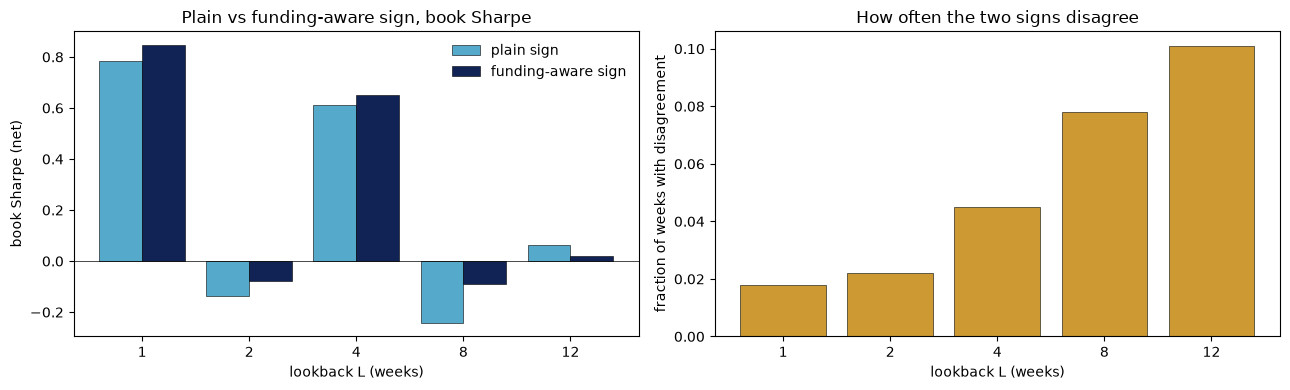

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(len(LOOKBACKS))
w = 0.4
ax1.bar(x - w/2, grid['plain_sharpe'], width=w, label='plain sign', color='#5ac', edgecolor='k', linewidth=0.4)
ax1.bar(x + w/2, grid['aware_sharpe'], width=w, label='funding-aware sign', color='#125', edgecolor='k', linewidth=0.4)
ax1.axhline(0, color='k', lw=0.5)
ax1.set_xticks(x); ax1.set_xticklabels([str(L) for L in LOOKBACKS])
ax1.set_xlabel('lookback L (weeks)')
ax1.set_ylabel('book Sharpe (net)')
ax1.set_title('Plain vs funding-aware sign, book Sharpe')
ax1.legend(frameon=False)

ax2.bar(x, grid['signal_disagree_frac'], color='#c93', edgecolor='k', linewidth=0.4)
ax2.set_xticks(x); ax2.set_xticklabels([str(L) for L in LOOKBACKS])
ax2.set_xlabel('lookback L (weeks)')
ax2.set_ylabel('fraction of weeks with disagreement')
ax2.set_title('How often the two signs disagree')
plt.tight_layout()
plt.show()


The disagreement rate grows monotonically with L, from about 2 percent at L=1 to about 10 percent at L=12, matching the mechanism. Most weeks the two signs are the same and the trade is identical. The lift on the book Sharpe rests on the minority of weeks where the trailing funding was large enough to flip the sign.


## By year

2022 was a mixed funding year, sometimes negative. 2023 and 2024 were persistently positive-funding. If the mechanism is real, the funding-aware lift should show mostly in 2023 and 2024, where a plain long paid heavy funding and the correction cools the sign toward flat or short in the marginal weeks.


plain sign, Sharpe by year
        1     2     4     8     12
2022  0.91  0.06  0.66 -0.60  0.35
2023  0.76 -0.31  0.64 -0.15 -1.22
2024  0.66 -0.19  0.54 -0.04  0.86
funding-aware sign, Sharpe by year
        1     2     4     8     12
2022  0.94  0.04  0.65 -0.17  0.48
2023  0.86 -0.10  0.73 -0.19 -1.09
2024  0.73 -0.18  0.60  0.05  0.60


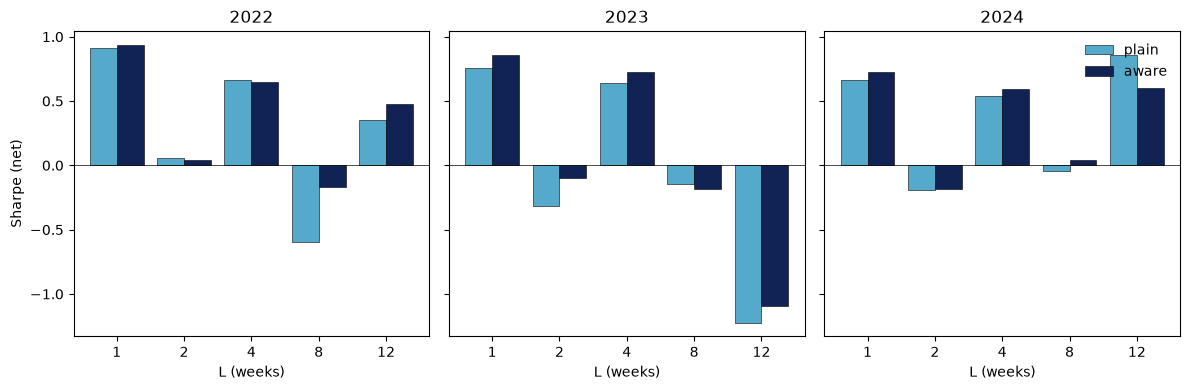

In [4]:
def sharpe_by_year(book):
    df = pd.DataFrame({'pnl': book.values}, index=book.index)
    return df.groupby(df.index.year)['pnl'].apply(
        lambda s: s.mean()/s.std()*np.sqrt(52) if s.std()>0 else np.nan)

years = sorted(set(results[1]['plain_pnl'].mean(axis=1).index.year))

plain_yr = pd.DataFrame({L: sharpe_by_year(results[L]['plain_pnl'].mean(axis=1)) for L in LOOKBACKS}).reindex(years)
aware_yr = pd.DataFrame({L: sharpe_by_year(results[L]['aware_pnl'].mean(axis=1)) for L in LOOKBACKS}).reindex(years)
print('plain sign, Sharpe by year')
print(plain_yr.round(2))
print('funding-aware sign, Sharpe by year')
print(aware_yr.round(2))

fig, axes = plt.subplots(1, len(years), figsize=(4*len(years), 4), sharey=True)
x = np.arange(len(LOOKBACKS))
w = 0.4
for ax, y in zip(axes, years):
    ax.bar(x - w/2, plain_yr.loc[y].values, width=w, label='plain', color='#5ac', edgecolor='k', linewidth=0.4)
    ax.bar(x + w/2, aware_yr.loc[y].values, width=w, label='aware', color='#125', edgecolor='k', linewidth=0.4)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels([str(L) for L in LOOKBACKS])
    ax.set_xlabel('L (weeks)')
    ax.set_title(str(y))
axes[0].set_ylabel('Sharpe (net)')
axes[-1].legend(frameon=False, loc='upper right')
plt.tight_layout()
plt.show()


At L=1 the lift is 0.03 in 2022, 0.10 in 2023, and 0.07 in 2024. At L=4 it is minus 0.01 in 2022, 0.09 in 2023, and 0.06 in 2024. The lift concentrates in the two positive-funding years, exactly the direction the mechanism predicts.


## Equity

Cumulative weekly return of the two winners under each sign. A visible gap means the funding correction changes the trade in a way that compounds. A tight cluster means it does not.


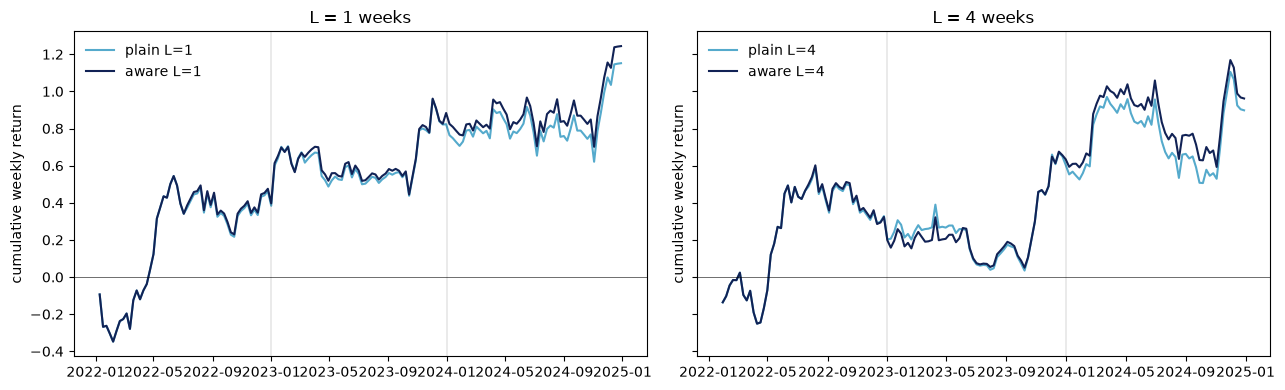

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, L in zip(axes, [1, 4]):
    plain_book = results[L]['plain_pnl'].mean(axis=1)
    aware_book = results[L]['aware_pnl'].mean(axis=1)
    ax.plot(plain_book.fillna(0).cumsum().index, plain_book.fillna(0).cumsum().values,
            label=f'plain L={L}', color='#5ac', lw=1.5)
    ax.plot(aware_book.fillna(0).cumsum().index, aware_book.fillna(0).cumsum().values,
            label=f'aware L={L}', color='#125', lw=1.5)
    ax.axhline(0, color='k', lw=0.4)
    for y in [2023, 2024]:
        ax.axvline(pd.Timestamp(f'{y}-01-01', tz='UTC'), color='k', lw=0.3, alpha=0.4)
    ax.set_title(f'L = {L} weeks')
    ax.set_ylabel('cumulative weekly return')
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()


The two paths track each other closely through 2022 when funding is not systematically hot. They separate progressively across 2023 and 2024, with the funding-aware path pulling ahead as the correction avoids some of the funding-heavy longs the plain sign takes on.


## Cost sensitivity of the funding-aware book

Same 0x, 1x, 2x check as the plain sweep. A funding-aware winner that flips sign between 1x and 2x cost is not robust.


cost_x   0.0   1.0   2.0
L                       
1       0.92  0.85  0.77
2      -0.02 -0.08 -0.13
4       0.69  0.65  0.62
8      -0.06 -0.09 -0.12
12      0.05  0.02 -0.00


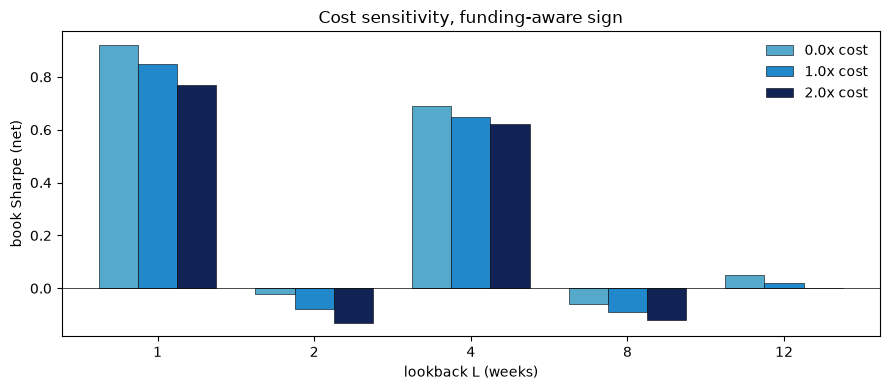

In [6]:
cost_mults = [0.0, 1.0, 2.0]
rows = []
for L in LOOKBACKS:
    _, aware = signals(L)
    for m in cost_mults:
        book = trend_pnl(aware, cost_mult=m).mean(axis=1)
        rows.append({'L': L, 'cost_x': m, 'sharpe': book_sharpe(book)})
cs = pd.DataFrame(rows).pivot(index='L', columns='cost_x', values='sharpe').round(2)
print(cs)

fig, ax = plt.subplots(figsize=(9, 4))
w = 0.25
x = np.arange(len(LOOKBACKS))
for i, m in enumerate(cost_mults):
    ax.bar(x + (i-1)*w, cs[m].values, width=w, label=f'{m}x cost',
           color=['#5ac','#28c','#125'][i], edgecolor='k', linewidth=0.4)
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels([str(L) for L in LOOKBACKS])
ax.set_xlabel('lookback L (weeks)')
ax.set_ylabel('book Sharpe (net)')
ax.set_title('Cost sensitivity, funding-aware sign')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


L=1 and L=4 keep their positive Sharpe at 2x cost. Cost drag is on the same scale as the plain sign because flip rates are barely changed by the correction. The losing cells stay negative at every cost multiplier.


## Finding

The funding-aware sign lifts every positive cell in the grid. L=1 goes from 0.79 to 0.85 and L=4 goes from 0.61 to 0.65. The lift concentrates in 2023 and 2024, the persistently positive-funding years, and the disagreement fraction is small (2 percent of weeks at L=1, 5 percent at L=4). Most weeks the two signs agree and the trade is unchanged. The mechanism is directional and the sign of the lift is stable across years.

The soft part is size. The delta is inside the noise of a three-year sample. Two to five percent of weeks changed sign is 3 to 8 marginal weeks per symbol, thin evidence taken alone. L=1 at 0.85 pooled Sharpe is essentially tied with long-only vol-scaled at 0.87, but keeps the regime map that wins 2022. The correction is worth carrying forward.
